In [2]:
import pandas as pd
import torch
import torch.nn as nn

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
df = pd.read_csv('data/Eng-Fra.csv')
df.head()

,English,French
0,Go.,Va !
1,Go.,Marche.
2,Go.,En route !
3,Go.,Bouge !
4,Hi.,Salut !


In [5]:
from preprocessing.normalize import normalize_text

df['English'] = df['English'].apply(normalize_text)
df['French'] = df['French'].apply(normalize_text)

In [6]:
df.head()

,English,French
0,go,va
1,go,marche
2,go,en route
3,go,bouge
4,hi,salut


In [7]:
pairs = []

for eng, fr in zip(df['English'], df['French']):
    pairs.append((eng,fr))

In [8]:
len(pairs)

239189

In [9]:
from preprocessing.vocabulary import Vocabulary

eng_vocab = Vocabulary("eng")
fr_vocab = Vocabulary("fr")

# Step 1: count words
for eng, fr in pairs:
    eng_vocab.add_sentence(eng)
    fr_vocab.add_sentence(fr)

# Step 2: build vocab (top-K)
eng_vocab.build_vocab(max_size=10000)
fr_vocab.build_vocab(max_size=10000)

In [9]:
from preprocessing.sentence_to_tensor import sentence_to_tensor
print(eng_vocab.vocab_size)
print(fr_vocab.vocab_size)

print(sentence_to_tensor(eng_vocab, "i am cold"))

10004
10004
tensor([  0,   4, 147, 306,   1])


In [10]:
from torch.utils.data import DataLoader
from preprocessing.dataset import TranslationDataset, collate_fn

dataset = TranslationDataset(pairs, eng_vocab, fr_vocab)

dataloader = DataLoader(
    dataset,
    batch_size = 32,
    shuffle = True,
    collate_fn = collate_fn
)

In [11]:
for src, trg in dataloader:
    print(src.shape)
    print(trg.shape)
    break

torch.Size([32, 13])
torch.Size([32, 17])


In [12]:
from models.seq2seq import Seq2Seq
from models.encoder import Encoder
from models.decoder import Decoder

encoder = Encoder(
    vocab_size = eng_vocab.vocab_size, 
    embedding_dim=256, 
    hidden_size = 512
    )
decoder = Decoder(
    vocab_size = fr_vocab.vocab_size, 
    embedding_dim= 256, 
    hidden_size = 512
    )

model = Seq2Seq(encoder, decoder, device)

In [13]:
print(encoder)
print(decoder)

Encoder(
  (embedding): Embedding(10004, 256)
  (gru): GRU(256, 512, batch_first=True)
)
Decoder(
  (embedding): Embedding(10004, 256)
  (gru): GRU(768, 512, batch_first=True)
  (fc): Linear(in_features=512, out_features=10004, bias=True)
  (attention): Attention(
    (attn): Linear(in_features=1024, out_features=512, bias=True)
    (v): Linear(in_features=512, out_features=1, bias=False)
  )
)


In [14]:
PAD_IDX = 2 # the tokens which should be ignored and must not affect the training process

criterion = torch.nn.CrossEntropyLoss(ignore_index = PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [15]:
num_epochs = 10
for epoch in range(num_epochs):
    total_loss = 0
    for src, trg in dataloader:

        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        decoder_input = trg[:, :-1]
        target = trg[:, 1:]

        output, attn_weights = model(src, decoder_input)

        output = output.reshape(-1, output.shape[-1])
        target = target.reshape(-1)

        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    avg_loss = total_loss/ len(dataloader)
    print(f"Epoch: {epoch+1}, Loss: {avg_loss:.4f}")

KeyboardInterrupt: 

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("seq2seq_attention.pth", map_location=device)

# Rebuild vocab objects
eng_vocab.word2index = checkpoint["eng_vocab"]
fr_vocab.word2index = checkpoint["fr_vocab"]

# (optional) rebuild index2word if needed
eng_vocab.index2word = {v:k for k,v in eng_vocab.word2index.items()}
fr_vocab.index2word = {v:k for k,v in fr_vocab.word2index.items()}

# Recreate model
encoder = Encoder(
    vocab_size=len(eng_vocab.word2index),
    embedding_dim=checkpoint["config"]["embedding_dim"],
    hidden_size=checkpoint["config"]["hidden_size"]
)

decoder = Decoder(
    vocab_size=len(fr_vocab.word2index),
    embedding_dim=checkpoint["config"]["embedding_dim"],
    hidden_size=checkpoint["config"]["hidden_size"]
)

model = Seq2Seq(encoder, decoder, device).to(device)

# Load weights
model.load_state_dict(checkpoint["model_state_dict"])

# VERY IMPORTANT
model.eval()

print("Model loaded and ready.")

Model loaded and ready.


In [17]:
def translate_sentence(sentence):

    src = sentence_to_tensor(eng_vocab, sentence)
    src = (src.unsqueeze(0)).to(device)

    encoder_outputs, hidden = encoder(src)

    decoder_input =( torch.tensor([[fr_vocab.word2index["SOS"]]]).to(device))

    translated_tokens = []

    attn_list = []

    for _ in range(20):

        output, hidden, attn_weights = decoder(decoder_input, hidden, encoder_outputs)

        attn_list.append(attn_weights.cpu().detach().numpy())

        pred_token = output.argmax(2)

        pred_idx = pred_token.item()

        if pred_idx == fr_vocab.word2index["EOS"]:
            break

        translated_tokens.append(fr_vocab.index2word[pred_idx])

        decoder_input = pred_token

    return " ".join(translated_tokens), attn_list

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attention(attn, input_words, output_words):

    attn_matrix = np.vstack(attn)  # [target_len, src_len]

    plt.figure(figsize=(6,6))
    plt.imshow(attn_matrix, cmap='viridis')

    plt.xticks(range(len(input_words)), input_words, rotation=45)
    plt.yticks(range(len(output_words)), output_words)

    plt.xlabel("Input Sentence")
    plt.ylabel("Output Sentence")

    plt.colorbar()
    plt.show()

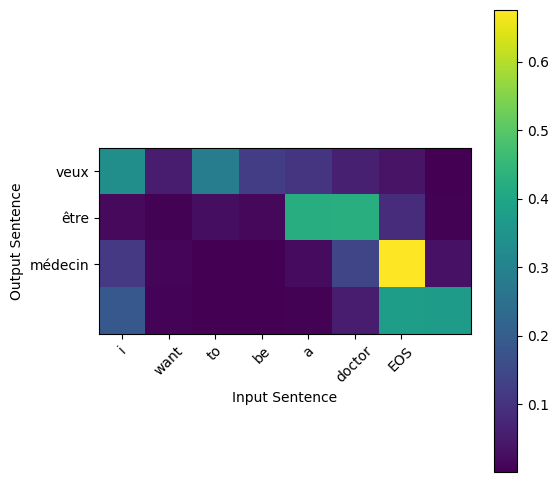

In [19]:
sentence = "i want to be a doctor"
translation, attn = translate_sentence(sentence)

input_words = sentence.split() + ["EOS"]
output_words = translation.split()

plot_attention(attn, input_words, output_words)

In [20]:
translation, attn = translate_sentence("i want to be a doctor")

print("Translation:", translation)
print("Attention shape:", len(attn))
print("Attention Weights:", attn)

Translation: veux être médecin
Attention shape: 4
Attention Weights: [array([[0.33531114, 0.05229759, 0.28490183, 0.12364664, 0.10464023,
        0.06035753, 0.03607668, 0.00276827]], dtype=float32), array([[0.01823694, 0.00402589, 0.02633585, 0.0155595 , 0.42137522,
        0.4244643 , 0.08613742, 0.00386498]], dtype=float32), array([[0.11311434, 0.01327389, 0.00103759, 0.00160763, 0.02100524,
        0.14156537, 0.6754034 , 0.03299242]], dtype=float32), array([[0.18662094, 0.0067363 , 0.00114899, 0.00107476, 0.00413198,
        0.05315438, 0.3759675 , 0.37116516]], dtype=float32)]


### **Adding Self Attention**

In [5]:
import torch
from models.self_attention import SelfAttention

x = torch.randn(2, 4, 8)
# batch = 2, seq_len = 4, d_model = 8

attn = SelfAttention(d_model = 8)

context, weights = attn(x)

print("Input shape: ",x.shape)
print("Context Shape: ",context.shape)
print("Weights shape: ",weights.shape)

Input shape:  torch.Size([2, 4, 8])
Context Shape:  torch.Size([2, 4, 8])
Weights shape:  torch.Size([2, 4, 4])


### **Applying Masking**

In [6]:
from utils.generate_mask import generate_mask

seq_len = x.shape[1]

mask = generate_mask(seq_len).to(device)
mask = mask.unsqueeze(0)

attn = SelfAttention(d_model = 8)

context, weights = attn(x, mask = mask)

print("Input shape: ",x.shape)
print("Context Shape: ",context.shape)
print("Weights shape: ",weights.shape)

print(weights)
print(context)

Input shape:  torch.Size([2, 4, 8])
Context Shape:  torch.Size([2, 4, 8])
Weights shape:  torch.Size([2, 4, 4])
tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.4056, 0.5944, 0.0000, 0.0000],
         [0.3485, 0.2613, 0.3902, 0.0000],
         [0.1248, 0.2386, 0.2795, 0.3572]],

        [[1.0000, 0.0000, 0.0000, 0.0000],
         [0.5402, 0.4598, 0.0000, 0.0000],
         [0.3236, 0.2598, 0.4166, 0.0000],
         [0.2784, 0.2145, 0.1900, 0.3172]]], grad_fn=<SoftmaxBackward0>)
tensor([[[-0.5543, -0.1550,  1.4069,  0.7351,  0.4705,  1.6787, -0.7232,
           0.9840],
         [-0.3431, -0.5169,  0.9660,  0.0882,  0.2579,  0.9448, -0.7935,
           0.6119],
         [-0.6838, -0.2334,  1.0896, -0.0357,  0.4193,  1.0128, -0.4051,
           0.5660],
         [-0.5300, -0.5857,  0.6677, -0.2981,  0.3936,  0.3421, -0.4775,
           0.2588]],

        [[-0.2791,  0.3041,  0.8749,  0.1586, -0.3091, -0.1560, -0.4831,
           0.0491],
         [-0.1691,  0.3083,  0.8818,  0.0493,

In [7]:
from models.multihead_attention import MultiHeadAttention

mha  = MultiHeadAttention(d_model = 8, num_heads = 2)
outputs, weights = mha(x)

print(outputs.shape)
print(weights.shape)

torch.Size([2, 4, 8])
torch.Size([2, 2, 4, 4])
